In [ ]:
!pip install textblob wordcloud

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob
from wordcloud import WordCloud

In [ ]:
df = pd.read_csv('/content/archive (1).zip')

In [ ]:
df.head()

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime,day_diff,helpful_yes,total_vote
0,A3SBTW3WS4IQSN,B007WTAJTO,NaN,"[0, 0]",No issues.,4.0,Four Stars,1406073600,2014-07-23,138,0,0
1,A18K1ODH1I2MVB,B007WTAJTO,0mie,"[0, 0]","Purchased this for my device, it worked as adv...",5.0,MOAR SPACE!!!,1382659200,2013-10-25,409,0,0
2,A2FII3I2MBMUIA,B007WTAJTO,1K3,"[0, 0]",it works as expected. I should have sprung for...,4.0,nothing to really say....,1356220800,2012-12-23,715,0,0
3,A3H99DFEG68SR,B007WTAJTO,1m2,"[0, 0]",This think has worked out great.Had a diff. br...,5.0,Great buy at this price!!! *** UPDATE,1384992000,2013-11-21,382,0,0
4,A375ZM4U047O79,B007WTAJTO,2&amp;1/2Men,"[0, 0]","Bought it with Retail Packaging, arrived legit...",5.0,best deal around,1373673600,2013-07-13,513,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4915 entries, 0 to 4914
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   reviewerID      4915 non-null   object 
 1   asin            4915 non-null   object 
 2   reviewerName    4914 non-null   object 
 3   helpful         4915 non-null   object 
 4   reviewText      4914 non-null   object 
 5   overall         4915 non-null   float64
 6   summary         4915 non-null   object 
 7   unixReviewTime  4915 non-null   int64  
 8   reviewTime      4915 non-null   object 
 9   day_diff        4915 non-null   int64  
 10  helpful_yes     4915 non-null   int64  
 11  total_vote      4915 non-null   int64  
dtypes: float64(1), int64(4), object(7)
memory usage: 460.9+ KB


In [ ]:
df = df[['reviewText','overall']]

In [ ]:
df.columns = ['Review','Rating']

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

,0
Review,0
Rating,0


In [ ]:
def get_sentiment(rating):

    if rating >= 4:
        return 'Positive'

    elif rating == 3:
        return 'Neutral'

    else:
        return 'Negative'

df['Sentiment'] = df['Rating'].apply(get_sentiment)

In [ ]:
df.head()

,Review,Rating,Sentiment
0,No issues.,4.0,Positive
1,"Purchased this for my device, it worked as adv...",5.0,Positive
2,it works as expected. I should have sprung for...,4.0,Positive
3,This think has worked out great.Had a diff. br...,5.0,Positive
4,"Bought it with Retail Packaging, arrived legit...",5.0,Positive


In [ ]:
df['Sentiment'].value_counts()

,count
Sentiment,
Positive,4448
Negative,324
Neutral,142


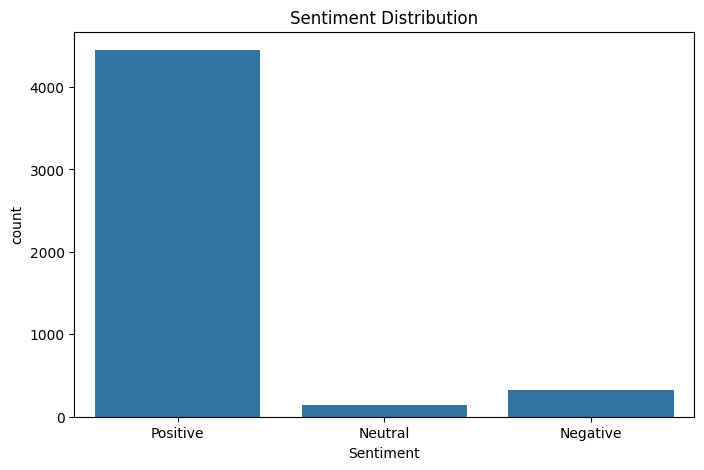

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Sentiment',
    data=df
)

plt.title('Sentiment Distribution')
plt.show()

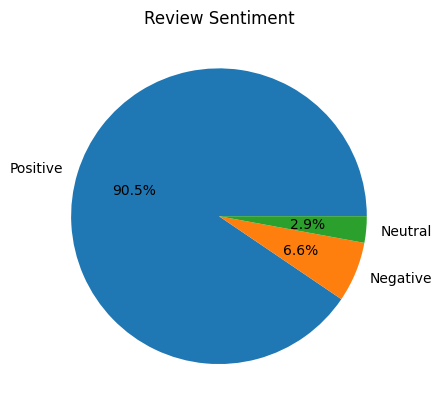

In [ ]:
df['Sentiment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')
plt.title('Review Sentiment')
plt.show()

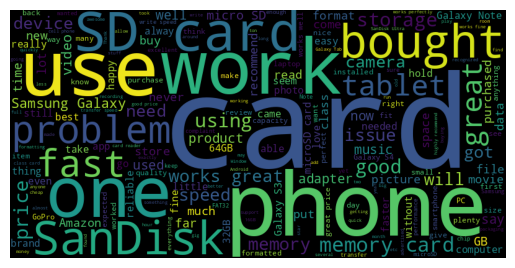

In [ ]:
positive_reviews = " ".join(
    df[df['Sentiment']=='Positive']['Review']
)

wordcloud = WordCloud(
    width=800,
    height=400
).generate(positive_reviews)

plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [ ]:
df['Sentiment'].value_counts(normalize=True)*100

,proportion
Sentiment,
Positive,90.516891
Negative,6.593407
Neutral,2.889703


In [ ]:
df.to_csv(
    'amazon_sentiment_analysis.csv',
    index=False
)

In [ ]:
from google.colab import files
files.download('amazon_sentiment_analysis.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>